# 05 - Swing Outcomes by Pitch Type

## MLB Ballpark Effects on Pitch Type Frequency & Contact Quality

This notebook conducts **Layer 2** of the three-layer analytical framework — examining whether swing outcomes (whiff, foul, in play) differ by park and pitch type across the sample.

Whiff and foul rates are computed per park per pitch type and compared against the league-wide baseline established in `02_eda.ipynb`. Deviations from that baseline are the signal of interest here.

No contact quality data is used in this notebook — SOV and batted ball quality are examined in notebook 06.

*Sample*: 173,137 swings across 29 parks (2023–2025 pooled)
<br>
*Granularity*: Park-level swing outcomes by pitch type (Level 1 classification)
<br>
*Baseline*: League-wide whiff and foul rates from EDA

___
## 1) Setup & Data Load

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

#  Database connection 
DB_PATH = Path(r"C:\Users\Bryce Gelarden\OneDrive - Indiana University\Documents\Github - brycemgelarden\MLB_Ballpark_Factor_Analysis\database\mlb_ballpark_effects.db")

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT * FROM swings", conn)
conn.close()

#  Color scheme (project-wide) 
COLORS = {
    "Fastball":  "#1F4E79",
    "Breaking":  "#2E75B6",
    "Offspeed":  "#9DC3E6",
    "reference": "#9DC3E6",
}

#  Outcomes color scheme 
OUTCOME_COLORS = {
    "whiff":   "#C00000",
    "foul":    "#F4B942",
    "in_play": "#70AD47",
}

In [2]:
# Validation

n_rows  = len(df)
n_parks = df["home_team"].nunique()

print(f"Rows loaded:  {n_rows:,}")
print(f"Parks loaded: {n_parks}")
print(f"\nSwing outcomes present:\n{df['swing_outcome'].value_counts()}")
print(f"\nPitch categories present:\n{df['pitch_category'].value_counts()}")

Rows loaded:  173,137
Parks loaded: 29

Swing outcomes present:
swing_outcome
foul       65205
in_play    63777
whiff      44155
Name: count, dtype: int64

Pitch categories present:
pitch_category
Fastball    96689
Breaking    51650
Offspeed    24798
Name: count, dtype: int64


___
## 2) League-Wide Baseline (Whiff, Foul, In-Play)

Baseline swing outcome rates are established here from the pooled sample 
(`02_eda.ipynb`) and serve as the reference point for all park-level 
deviation analysis in Sections 3–6.

In [3]:
# Overall Baseline

overall_baseline = (
    df["swing_outcome"]
    .value_counts(normalize=True)
    .reindex(["whiff", "foul", "in_play"]) * 100
)

print(f"League-Wide Swing Outcomes  (n = {len(df):,})\n")
print(overall_baseline.round(2).to_string())

League-Wide Swing Outcomes  (n = 173,137)

swing_outcome
whiff      25.50
foul       37.66
in_play    36.84


In [ ]:
# Baseline by Pitch Category

category_baseline = (
    df.groupby("pitch_category")["swing_outcome"]
    .value_counts(normalize=True)
    .unstack() * 100
)[["whiff", "foul", "in_play"]].loc[["Fastball", "Breaking", "Offspeed"]]

print(f"Swing Outcomes by Pitch Category  (n = {len(df):,})\n")
print(category_baseline.round(2).to_string())

Swing Outcomes by Pitch Category  (n = 173,137)

swing_outcome   whiff   foul  in_play
pitch_category                       
Fastball        20.16  42.20    37.65
Breaking        32.64  32.48    34.88
Offspeed        31.47  30.77    37.76


*For visual reference, see `02_eda.ipynb` Section 4 (Swing Outcome Distribution).*


___
## 3) Park-Level Outcome Rates (Overall)

In [7]:
# Overall whiff/foul/in_play rates per park across all pitch types (table)

park_outcomes = (
    df.groupby(["home_team", "swing_outcome"])
    .size()
    .unstack(fill_value=0)
)[["whiff", "foul", "in_play"]]

park_n = park_outcomes.sum(axis=1).rename("n")
park_outcome_rates = park_outcomes.div(park_n, axis=0) * 100
park_outcome_rates.insert(0, "n", park_n)

print(f"Park-Level Swing Outcome Rates  (n per park ≈ 5,970)\n")
print(park_outcome_rates.sort_values("whiff", ascending=False).round(2).to_string())

Park-Level Swing Outcome Rates  (n per park ≈ 5,970)

swing_outcome     n  whiff   foul  in_play
home_team                                 
SEA            5944  28.55  37.63    33.82
ATL            5927  28.06  37.20    34.74
LAA            5973  27.69  37.05    35.26
HOU            5978  27.57  35.90    36.53
NYM            5998  27.13  37.83    35.05
NYY            5999  27.05  37.72    35.22
TB             5981  27.05  38.09    34.86
DET            5965  26.35  36.56    37.08
CWS            5964  26.19  37.81    36.00
PHI            5993  26.08  38.93    34.99
TEX            5990  25.94  37.83    36.23
MIN            6000  25.88  38.43    35.68
MIA            5998  25.66  37.08    37.26
LAD            5988  25.58  38.54    35.87
PIT            6000  25.47  35.97    38.57
MIL            5903  25.33  38.35    36.32
BAL            5957  25.30  38.26    36.44
CIN            5953  25.10  37.73    37.17
SF             5966  24.91  36.57    38.52
COL            5994  24.84  36.35    38.81


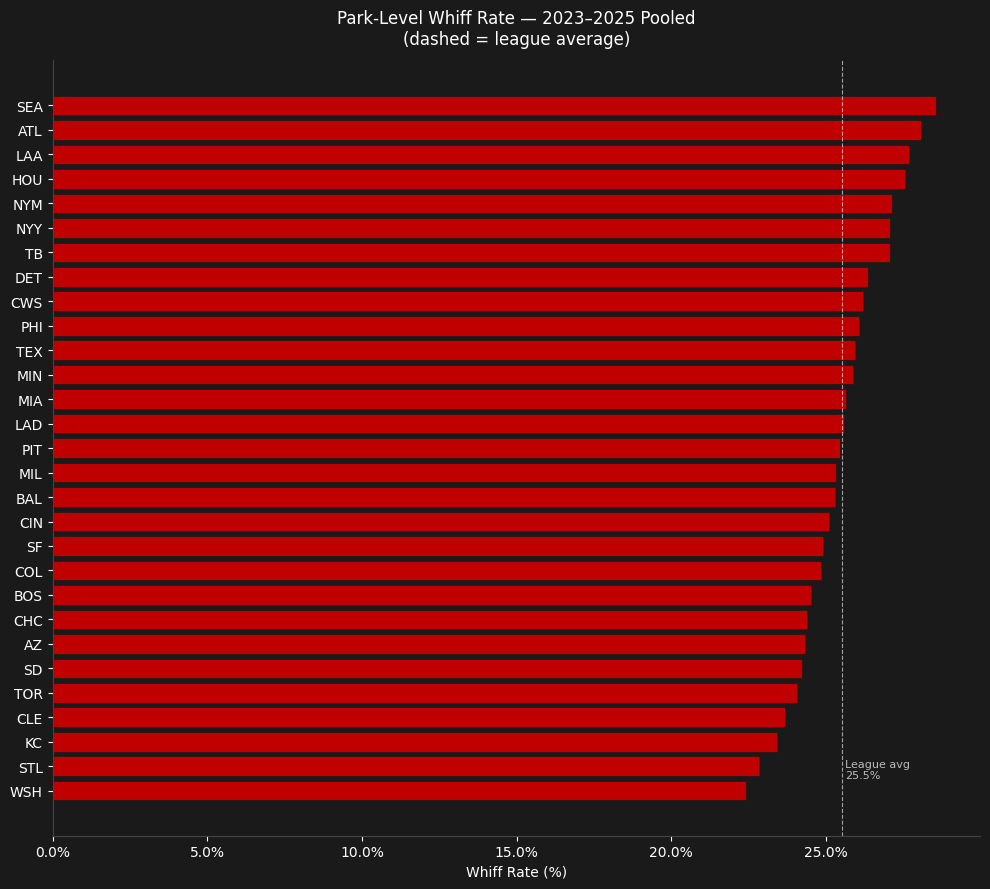

In [ ]:
# visualizing whiff rate at each park w/o pitch types

whiff_sorted = park_outcome_rates.sort_values("whiff", ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))

bars = ax.barh(
    whiff_sorted.index,
    whiff_sorted["whiff"],
    color=OUTCOME_COLORS["whiff"],
    edgecolor="#1a1a1a",
    linewidth=0.5,
)

# reference line of league average (whiff rate) 
league_whiff = overall_baseline["whiff"]
ax.axvline(league_whiff, color="white", linewidth=0.8, linestyle="--", alpha=0.6)
ax.text(league_whiff + 0.1, 0.5, f"League avg\n{league_whiff:.1f}%", 
        color="white", fontsize=8, alpha=0.7)

ax.set_title("Park-Level Whiff Rate — 2023–2025 Pooled\n(dashed = league average)",
             color="white", fontsize=12, pad=12)
ax.set_xlabel("Whiff Rate (%)", color="white")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

ax.set_facecolor("#1a1a1a")
fig.patch.set_facecolor("#1a1a1a")
ax.tick_params(colors="white")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#444444")

plt.tight_layout()
plt.show()

**SEA leads the sample in whiff rate by a considerable margin** which is consistent with the Mariners' identity as both a swing-and-miss pitching staff and a high-strikeout offensive environment. Also worth noting park-level whiff rates reflect both teams in every game, meaning teams' pitching and hitting tendencies are embedded in these numbers alongside any park effects.

**STL and WSH sit at the bottom of the whiff rate distribution** — and for STL, this is not surprising in context. `Notebook 04` established Busch Stadium a heavy sinker environment with an active FF → SI substitution pattern. Sinkers are not swing-and-miss pitches but weak contact pitches. Low whiff rate at Busch is the intended outcome of the pitching approach the data is reveals. This thread will be tested directly in `Notebook 06` when SOV brings the contact quality layer into focus.

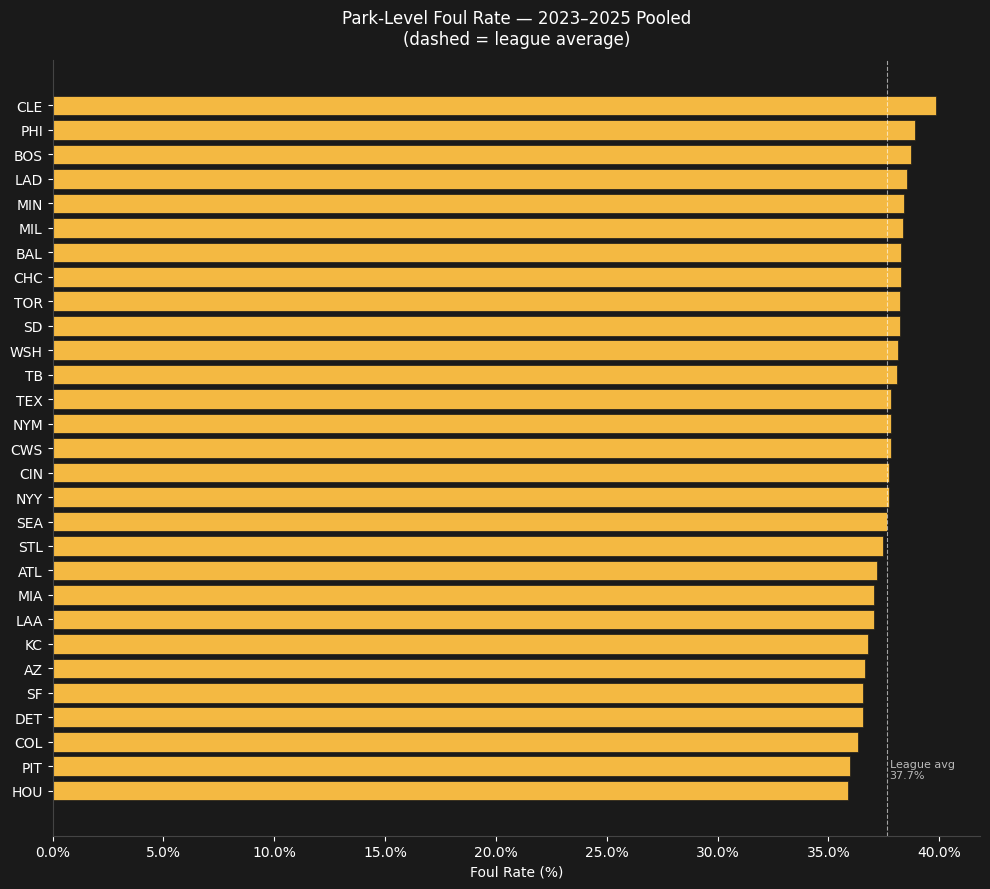

In [ ]:
# Visualizing foul rate at each park w/o pitch types

foul_sorted = park_outcome_rates.sort_values("foul", ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))

ax.barh(
    foul_sorted.index,
    foul_sorted["foul"],
    color=OUTCOME_COLORS["foul"],
    edgecolor="#1a1a1a",
    linewidth=0.5,
)

league_foul = overall_baseline["foul"]
ax.axvline(league_foul, color="white", linewidth=0.8, linestyle="--", alpha=0.6)
ax.text(league_foul + 0.1, 0.5, f"League avg\n{league_foul:.1f}%",
        color="white", fontsize=8, alpha=0.7)

ax.set_title("Park-Level Foul Rate — 2023–2025 Pooled\n(dashed = league average)",
             color="white", fontsize=12, pad=12)
ax.set_xlabel("Foul Rate (%)", color="white")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

ax.set_facecolor("#1a1a1a")
fig.patch.set_facecolor("#1a1a1a")
ax.tick_params(colors="white")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#444444")

plt.tight_layout()
plt.show()

Yellow chart above denotes the foul rates at each park, by process of elimination, we know which park has the highest in_play rate.  
<br>
Instead of showing that individually, a stacked bar chart is shown below:

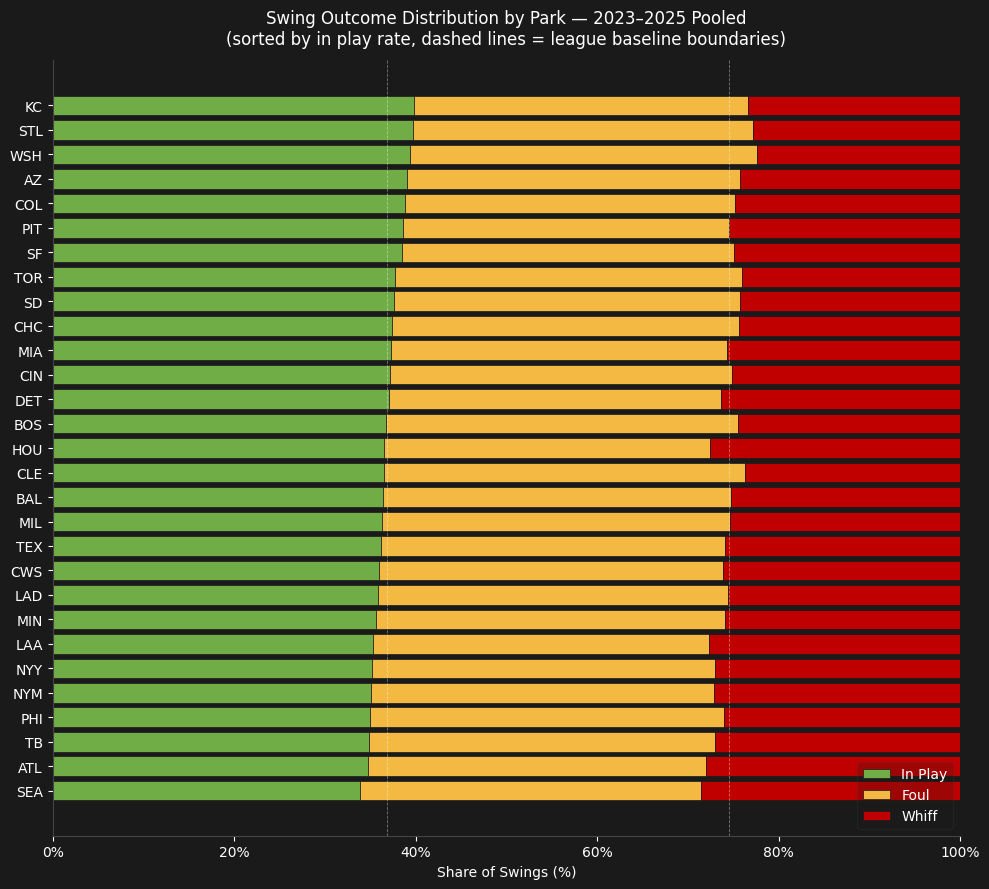

In [10]:
# sort by in_play rate descending — highest in_play parks on top
outcome_sorted = park_outcome_rates.sort_values("in_play", ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))

left = np.zeros(len(outcome_sorted))
for outcome in ["in_play", "foul", "whiff"]:
    values = outcome_sorted[outcome].values
    ax.barh(
        outcome_sorted.index,
        values,
        left=left,
        color=OUTCOME_COLORS[outcome],
        label=outcome.replace("_", " ").title(),
        edgecolor="#1a1a1a",
        linewidth=0.5,
    )
    left += values

# league average boundary reference lines
cumulative = 0
for outcome in ["in_play", "foul"]:
    cumulative += overall_baseline[outcome]
    ax.axvline(cumulative, color="white", linewidth=0.6, linestyle="--", alpha=0.4)

ax.set_xlabel("Share of Swings (%)", color="white")
ax.set_title("Swing Outcome Distribution by Park — 2023–2025 Pooled\n(sorted by in play rate, dashed lines = league baseline boundaries)",
             color="white", fontsize=12, pad=12)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, 100)

ax.set_facecolor("#1a1a1a")
fig.patch.set_facecolor("#1a1a1a")
ax.tick_params(colors="white")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#444444")

ax.legend(
    loc="lower right",
    framealpha=0.2,
    labelcolor="white",
    facecolor="#1a1a1a",
    edgecolor="#444444",
)

plt.tight_layout()
plt.show()

___
## 4) Park-Level Outcome Rates by Pitch Type

In [11]:
# outcome rates per park per pitch category
park_category_outcomes = (
    df.groupby(["home_team", "pitch_category", "swing_outcome"])
    .size()
    .unstack(fill_value=0)
)[["whiff", "foul", "in_play"]]

park_category_n = park_category_outcomes.sum(axis=1).rename("n")
park_category_rates = park_category_outcomes.div(park_category_n, axis=0) * 100
park_category_rates.insert(0, "n", park_category_n)

print("Park-Level Outcome Rates by Pitch Category\n")
for cat in ["Fastball", "Breaking", "Offspeed"]:
    print(f"\n── {cat} ──────────────────────────────")
    subset = park_category_rates.xs(cat, level="pitch_category")
    print(subset.sort_values("whiff", ascending=False).round(2).to_string())

Park-Level Outcome Rates by Pitch Category


── Fastball ──────────────────────────────
swing_outcome     n  whiff   foul  in_play
home_team                                 
TB             3398  24.34  40.64    35.02
SEA            3316  24.34  41.65    34.02
NYM            3515  22.67  42.13    35.19
CWS            3311  22.26  42.62    35.13
LAA            3222  22.10  41.81    36.10
TEX            3357  22.04  41.97    35.98
MIN            3334  21.87  42.23    35.90
ATL            3109  21.74  42.49    35.77
HOU            3264  21.17  40.44    38.39
MIL            3666  21.09  42.42    36.50
NYY            3441  20.78  42.84    36.38
BAL            3333  20.70  43.56    35.73
PHI            3393  20.45  43.21    36.34
TOR            3475  20.26  42.62    37.12
CIN            3345  19.76  42.45    37.79
DET            3227  19.71  41.09    39.20
MIA            3250  19.60  41.26    39.14
SF             3149  19.40  41.47    39.12
LAD            3334  19.26  43.37    37.37
PIT      

In [ ]:
# Deviation from league-wide category baseline established from Section 2
deviations = {}
for cat in ["Fastball", "Breaking", "Offspeed"]:
    park_rates = park_category_rates.xs(cat, level="pitch_category")[["whiff", "foul", "in_play"]]
    baseline   = category_baseline.loc[cat, ["whiff", "foul", "in_play"]]
    deviations[cat] = park_rates.subtract(baseline, axis=1)

print("Deviation from League Baseline by Pitch Category (percentage points)\n")
for cat in ["Fastball", "Breaking", "Offspeed"]:
    print(f"\n── {cat} ──────────────────────────────")
    print(deviations[cat].sort_values("whiff", ascending=False).round(2).to_string())

Deviation from League Baseline by Pitch Category (percentage points)


── Fastball ──────────────────────────────
swing_outcome  whiff  foul  in_play
home_team                          
TB              4.18 -1.56    -2.62
SEA             4.18 -0.55    -3.63
NYM             2.52 -0.06    -2.45
CWS             2.10  0.42    -2.52
LAA             1.94 -0.39    -1.55
TEX             1.89 -0.23    -1.66
MIN             1.71  0.03    -1.74
ATL             1.59  0.29    -1.88
HOU             1.01 -1.76     0.74
MIL             0.93  0.22    -1.15
NYY             0.62  0.64    -1.26
BAL             0.55  1.37    -1.91
PHI             0.30  1.01    -1.31
TOR             0.10  0.42    -0.52
CIN            -0.40  0.25     0.14
DET            -0.45 -1.11     1.56
MIA            -0.56 -0.94     1.49
SF             -0.75 -0.72     1.48
LAD            -0.90  1.17    -0.27
PIT            -0.99 -1.87     2.86
CLE            -1.32  2.13    -0.81
BOS            -1.32  1.29     0.03
SD             -1.63  

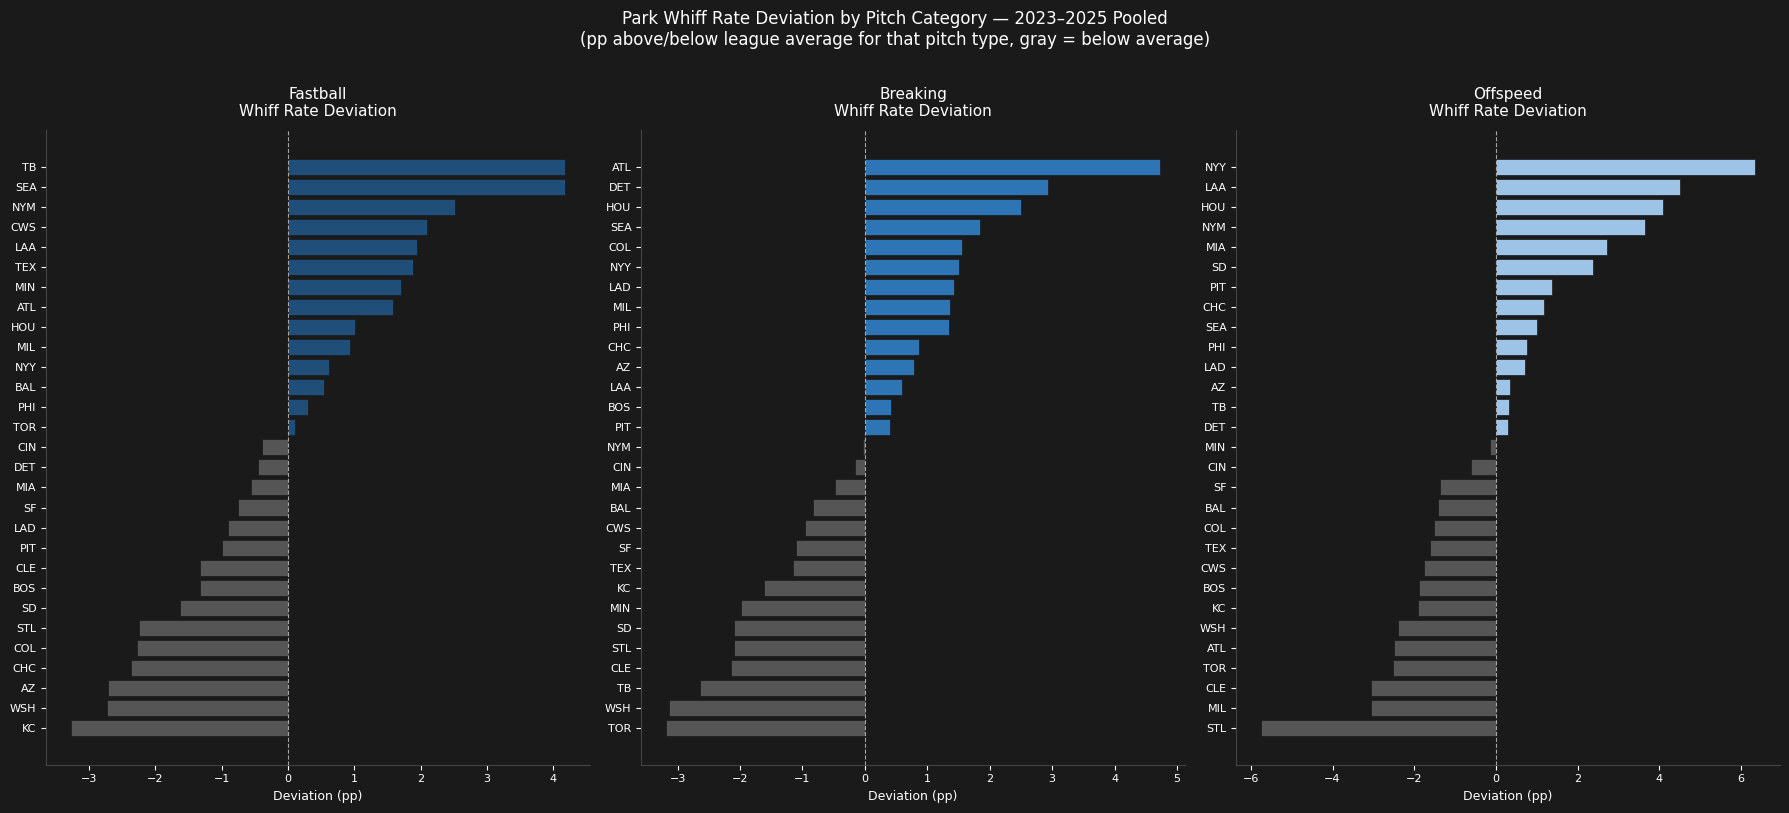

In [ ]:
# Visualizing Whiff Rate Deviations by Pitch Category (Level 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharey=False)

for ax, cat in zip(axes, ["Fastball", "Breaking", "Offspeed"]):
    dev = deviations[cat]["whiff"].sort_values(ascending=True)
    colors = [COLORS[cat] if v > 0 else "#555555" for v in dev.values]
    
    ax.barh(
        dev.index,
        dev.values,
        color=colors,
        edgecolor="#1a1a1a",
        linewidth=0.5,
    )
    ax.axvline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.set_title(f"{cat}\nWhiff Rate Deviation", color="white", fontsize=11, pad=10)
    ax.set_xlabel("Deviation (pp)", color="white", fontsize=9)
    ax.tick_params(colors="white", labelsize=8)
    ax.set_facecolor("#1a1a1a")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#444444")

fig.patch.set_facecolor("#1a1a1a")
fig.suptitle(
    "Park Whiff Rate Deviation by Pitch Category — 2023–2025 Pooled\n(pp above/below league average for that pitch type, gray = below average)",
    color="white", fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

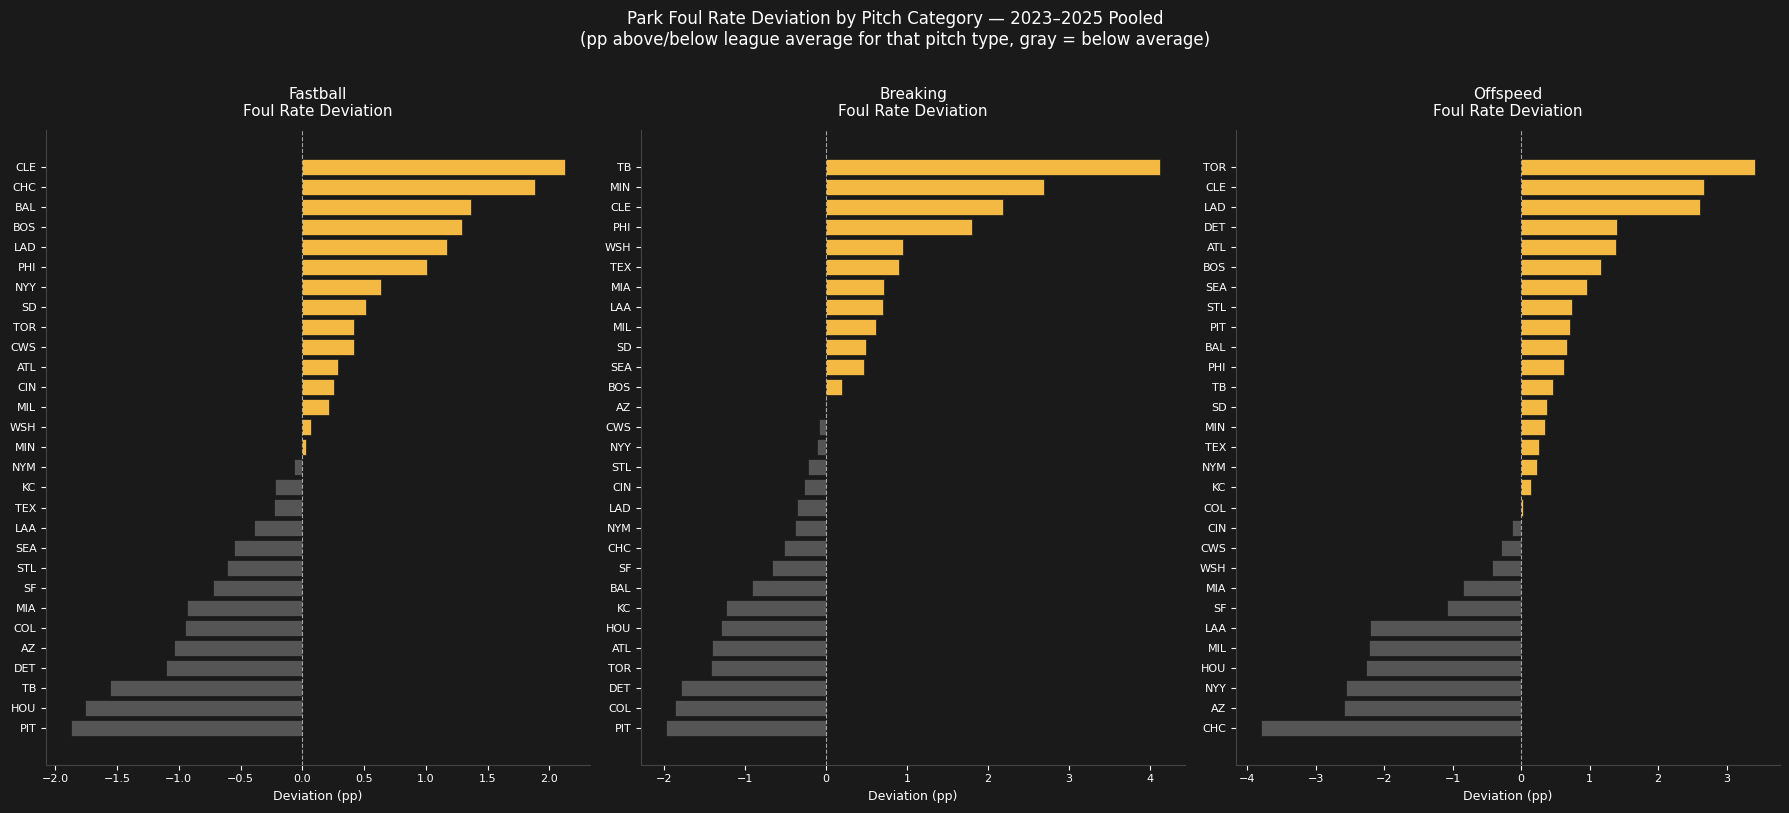

In [ ]:
# Visualizing Foul Ball Rate Deviations by Pitch Category (Level 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 8), sharey=False)

for ax, cat in zip(axes, ["Fastball", "Breaking", "Offspeed"]):
    dev = deviations[cat]["foul"].sort_values(ascending=True)
    colors = [OUTCOME_COLORS["foul"] if v > 0 else "#555555" for v in dev.values]
    
    ax.barh(
        dev.index,
        dev.values,
        color=colors,
        edgecolor="#1a1a1a",
        linewidth=0.5,
    )
    ax.axvline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.set_title(f"{cat}\nFoul Rate Deviation", color="white", fontsize=11, pad=10)
    ax.set_xlabel("Deviation (pp)", color="white", fontsize=9)
    ax.tick_params(colors="white", labelsize=8)
    ax.set_facecolor("#1a1a1a")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#444444")

fig.patch.set_facecolor("#1a1a1a")
fig.suptitle(
    "Park Foul Rate Deviation by Pitch Category — 2023–2025 Pooled\n(pp above/below league average for that pitch type, gray = below average)",
    color="white", fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

___
## 5) Deviation from Baseline

Chi-Square GOF Per Park, along with flagging summary

In [15]:
from scipy.stats import chisquare

# expected proportions from overall league baseline
expected_props = overall_baseline[["whiff", "foul", "in_play"]].values / 100

results = []
for park in park_outcomes.index:
    observed = park_outcomes.loc[park, ["whiff", "foul", "in_play"]].values
    n = observed.sum()
    expected = expected_props * n

    chi2, p = chisquare(f_obs=observed, f_exp=expected)

    results.append({
        "park":        park,
        "n":           n,
        "chi2":        round(chi2, 3),
        "p_value":     round(p, 4),
        "significant": p < 0.05,
    })

chi2_results = (
    pd.DataFrame(results)
    .set_index("park")
    .sort_values("chi2", ascending=False)
)

print("Chi-Square Goodness-of-Fit — Park Swing Outcomes vs. League Baseline\n")
print(chi2_results.to_string())

Chi-Square Goodness-of-Fit — Park Swing Outcomes vs. League Baseline

         n    chi2  p_value  significant
park                                    
SEA   5944  36.360   0.0000         True
WSH   5948  33.520   0.0000         True
STL   5992  29.845   0.0000         True
KC    5948  25.262   0.0000         True
ATL   5927  22.578   0.0000         True
LAA   5973  15.843   0.0004         True
CLE   5970  15.549   0.0004         True
HOU   5978  15.074   0.0005         True
AZ    5996  12.892   0.0016         True
TB    5981  12.257   0.0022         True
NYM   5998  11.462   0.0032         True
COL   5994  10.061   0.0065         True
NYY   5999   9.909   0.0071         True
PIT   6000   9.454   0.0089         True
PHI   5993   8.882   0.0118         True
SF    5966   7.283   0.0262         True
TOR   5999   6.722   0.0347         True
SD    5948   5.126   0.0771        False
BOS   5955   4.139   0.1263        False
CHC   5910   3.909   0.1417        False
DET   5965   3.700   0.1572 

In [16]:
sig_count = chi2_results["significant"].sum()
print(f"{sig_count} of 29 parks deviate significantly from league outcome baseline (p < 0.05)")
print(f"{29 - sig_count} parks are statistically indistinguishable from league average")
print(f"\nTop 5 deviating parks:")
print(chi2_results.head(5).to_string())

17 of 29 parks deviate significantly from league outcome baseline (p < 0.05)
12 parks are statistically indistinguishable from league average

Top 5 deviating parks:
         n    chi2  p_value  significant
park                                    
SEA   5944  36.360      0.0         True
WSH   5948  33.520      0.0         True
STL   5992  29.845      0.0         True
KC    5948  25.262      0.0         True
ATL   5927  22.578      0.0         True


___
## 6) Statistical Significance

___
## 7) Observations & Forward Look